<a href="https://colab.research.google.com/github/alt-gabby/qml-assignments/blob/main/2_Quantum%20Kernels%20for%20nonlinear%20classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pennylane scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 36.6 MB/s eta 0:00:00


#Solution to Exercise 2 on Quantum Kernel Methods for Nonlinear Classification


First I'll generate a nonlinear binary classification dataset. The moons dataset is not linearly separable.



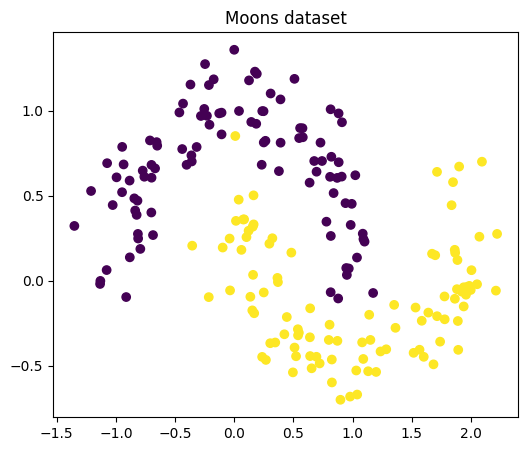

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(
    n_samples=200,
    noise=0.15,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Moons dataset")
plt.show()

# Train and evaluate using Classical Linear SVM


In [3]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

linear_svm = SVC(kernel="linear")

linear_svm.fit(X_train, y_train)

pred_linear = linear_svm.predict(X_test)

acc_linear = accuracy_score(
    y_test,
    pred_linear
)

print(acc_linear)

0.8333333333333334


# Train and evaluate using Classical RBF SVM

In [4]:
rbf_svm = SVC(kernel="rbf")

rbf_svm.fit(X_train, y_train)

pred_rbf = rbf_svm.predict(X_test)

acc_rbf = accuracy_score(
    y_test,
    pred_rbf
)

print(acc_rbf)

0.9833333333333333


# Build the Quantum Feature Map

In [5]:
import pennylane as qml

n_qubits = 2

dev = qml.device(
    "default.qubit",
    wires=n_qubits
)

In [6]:
#def feature_map(x):

    qml.Hadamard(0)
    qml.Hadamard(1)

    qml.RZ(x[0], wires=0)
    qml.RZ(x[1], wires=1)

    qml.CNOT(wires=[0,1])

    qml.RZ(
        (np.pi - x[0])*(np.pi - x[1]),
        wires=1
    )

    qml.CNOT(wires=[0,1])

In [37]:
def feature_map(x):
    qml.Hadamard(0)
    qml.Hadamard(1)

    qml.RZ(x[0], wires=0)
    qml.RZ(x[1], wires=1)

    qml.CNOT(wires=[0,1])
    qml.RZ((np.pi - x[0])*(np.pi - x[1]), wires=1)
    qml.CNOT(wires=[0,1])

    qml.RZ(x[0], wires=0)
    qml.RZ(x[1], wires=1)

# Define the Quantum Kernel

In [38]:
@qml.qnode(dev)
def kernel_circuit(x1, x2):

    feature_map(x1)

    qml.adjoint(feature_map)(x2)

    return qml.probs(wires=[0,1])

In [39]:
#kernel function

def quantum_kernel(x1, x2):

    return kernel_circuit(x1, x2)[0]

# Build Kernel Matrix

In [40]:
def kernel_matrix(A, B):

    return np.array(
        [
            [quantum_kernel(a,b) for b in B]
            for a in A
        ]
    )

In [41]:
K_train = kernel_matrix(
    X_train,
    X_train
)

K_test = kernel_matrix(
    X_test,
    X_train
)

# Quantum Kernel SVM

In [42]:
quantum_svm = SVC(kernel="precomputed")

quantum_svm.fit(
    K_train,
    y_train
)

pred_quantum = quantum_svm.predict(
    K_test
)

acc_quantum = accuracy_score(
    y_test,
    pred_quantum
)

print(acc_quantum)

0.8833333333333333


# Accuracy Comparison

In [43]:
print("Linear :", acc_linear)
print("RBF    :", acc_rbf)
print("Quantum:", acc_quantum)

Linear : 0.8333333333333334
RBF    : 0.9833333333333333
Quantum: 0.8833333333333333


# RBF Kernel Matrix

In [44]:
from sklearn.metrics.pairwise import rbf_kernel

K_rbf = rbf_kernel(X_train)

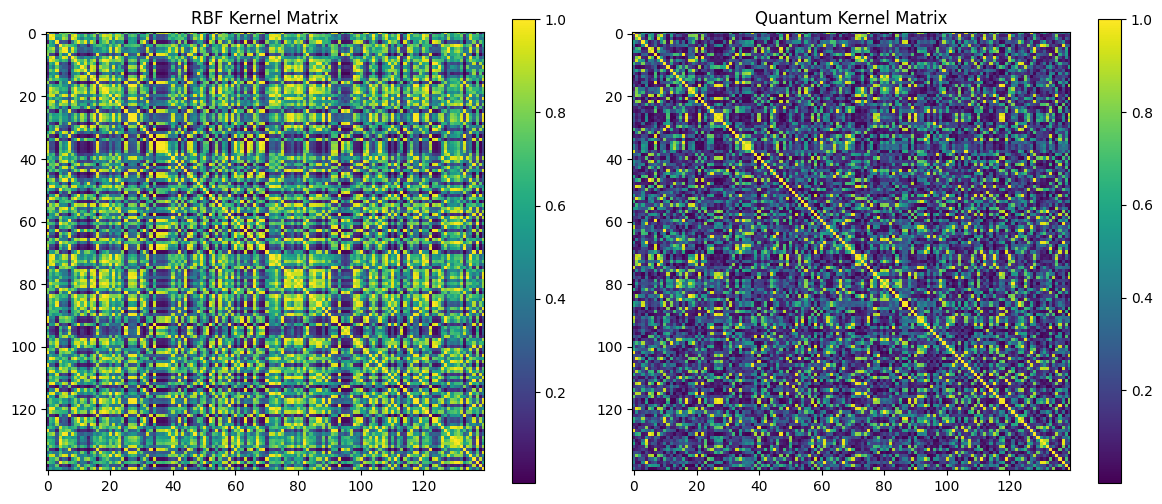

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(K_rbf)
axes[0].set_title("RBF Kernel Matrix")
plt.colorbar(axes[0].images[0], ax=axes[0])

axes[1].imshow(K_train)
axes[1].set_title("Quantum Kernel Matrix")
plt.colorbar(axes[1].images[0], ax=axes[1])  # [0] not [1]

plt.tight_layout()
plt.show()

# Quantum Kernel Matrix

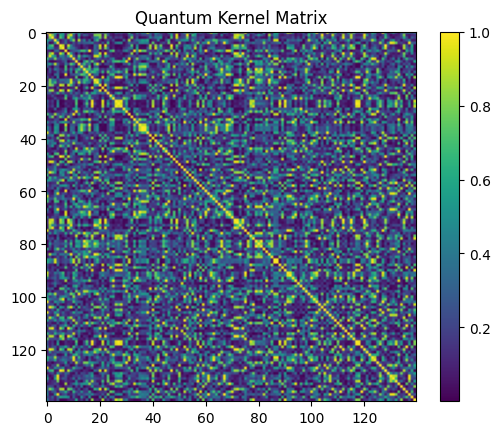

In [45]:
plt.imshow(K_train)
plt.colorbar()
plt.title("Quantum Kernel Matrix")
plt.show()

# Decision boundary function

In [61]:
def plot_boundary(model, X, y, title):

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min,x_max,20),
        np.linspace(y_min,y_max,20)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid)

    Z = Z.reshape(xx.shape)

    plt.contourf(xx,yy,Z,alpha=0.4)

    plt.scatter(
        X[:,0],
        X[:,1],
        c=y
    )

    plt.title(title)

    plt.show()

# Plot Linear and RBF boundaries


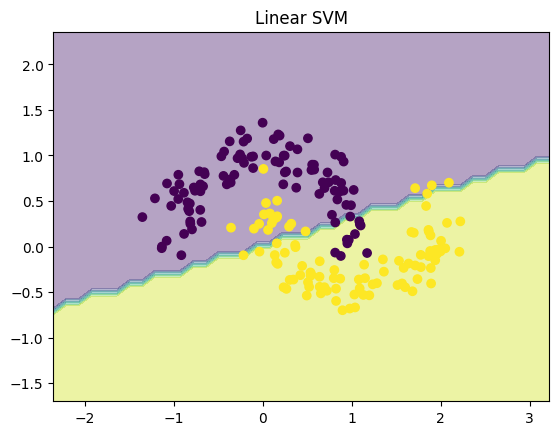

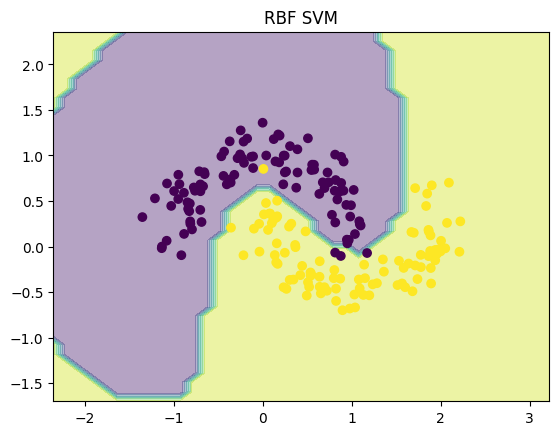

In [58]:
plot_boundary(
    linear_svm,
    X,
    y,
    "Linear SVM"
)

plot_boundary(
    rbf_svm,
    X,
    y,
    "RBF SVM"
)

# Quantum Decision Boundary


In [59]:
class QuantumModel:

    def predict(self, X_grid):

        K_grid = kernel_matrix(
            X_grid,
            X_train
        )

        return quantum_svm.predict(
            K_grid
        )

quantum_model = QuantumModel()

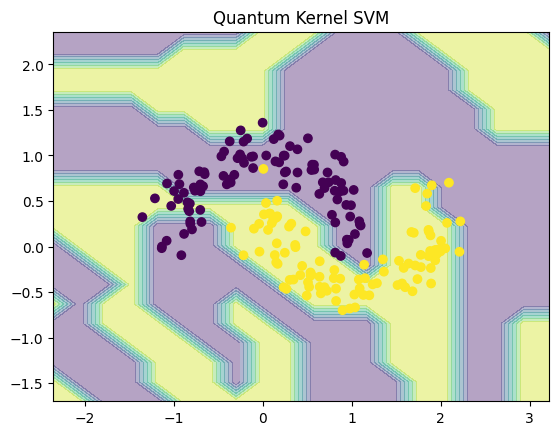

In [62]:
plot_boundary(
    quantum_model,
    X,
    y,
    "Quantum Kernel SVM"
)

The quantum feature map embeds classical data into a quantum Hilbert space using parameterized rotations and entangling gates. This nonlinear embedding changes the geometry of the data and enables similarities between samples to be measured through quantum state overlaps. Compared with the linear SVM, the quantum kernel captures nonlinear relationships and produces significantly better classification performance. Its behavior is qualitatively similar to the classical RBF kernel, although the induced feature space is generated by quantum operations rather than a classical analytic function.